## **SIBI Alphabet Recognition — CNN Training Notebook**

**Indonesian Sign Language (SIBI) — Alphabet A–Y (no J and K)**

**Pipeline SIBI's AI:**
- MediaPipe Hand Landmarker → bounding-box crop → CNN classification
- Note: This notebook focus on CNN modeling and Classification

**Hardware target:** Intel 12th-Gen i5-HX · NVIDIA RTX 2050 (4 GB VRAM)

**Key design choices:**
| Choice | Reason |
|---|---|
| Input size 128×128 | Fits comfortably in 4 GB VRAM with large batch |
| AMP FP16 | ~2× memory saving, ~1.5× speed-up on Turing/Ampere |
| No HorizontalFlip | SIBI handshapes are orientation-specific |
| AdamW + OneCycleLR | Strong generalisation, single-cycle convergence |
| SIBINet | ~2 M params, depthwise conv bottlenecks, fast & accurate |

### **Imports & Global Config**

In [1]:
from __future__ import annotations

import json
import math
import os
import random
import time
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm.notebook import tqdm

# Reproducibility 
SEED: int = 42

def set_seed(seed: int = SEED) -> None:
    """Fix all random seeds for reproducible training."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# CUDA optimisations 
torch.backends.cudnn.benchmark = True   
torch.backends.cudnn.deterministic = False  

DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU   : {props.name}  ({props.total_memory / 1e9:.1f} GB VRAM)")

Device: cuda
GPU   : NVIDIA GeForce RTX 2050  (4.3 GB VRAM)


### **Hyperparameters**

In [ ]:
# hyperparameters 

CFG: Dict = {
    # Paths
    "data_dir"       : "SIBI",          # root folder with A/, B/, … sub-dirs
    "output_dir"     : "outputs",
    "model_filename" : "sibi_cnn_best.pth",
    "class_map_file" : "class_to_idx.json",

    # Data
    "img_size"       : 128,             # resize to (img_size × img_size)
    "val_split"      : 0.15,            # fraction held out for validation
    "test_split"     : 0.10,            # fraction held out for final test

    # DataLoader
    "batch_size"     : 64,              # safe for 4 GB VRAM with FP16
    "num_workers"    : 0,               # 0 = main process (avoids Windows deadlock)
    "pin_memory"     : True,            # speeds up CPU→GPU transfer

    # Model
    "num_classes"    : 24,              # SIBI A-Y (no J, Z — static letters only)
    "dropout"        : 0.40,

    # Training
    "epochs"         : 50,
    "lr_max"         : 3e-3,            # OneCycleLR peak LR
    "weight_decay"   : 1e-4,
    "label_smoothing": 0.05,
    "use_amp"        : True,            # AMP FP16 (disable if DEVICE == cpu)

    # Early stopping
    "patience"       : 10,              # epochs without val improvement before stop
}

# Derived
CFG["use_amp"] = CFG["use_amp"] and (DEVICE.type == "cuda")
OUTPUT_DIR = Path(CFG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps({k: str(v) for k, v in CFG.items()}, indent=2))

{
  "data_dir": "SIBI",
  "output_dir": "outputs",
  "model_filename": "sibi_cnn_best.pth",
  "class_map_file": "class_to_idx.json",
  "img_size": "128",
  "val_split": "0.15",
  "test_split": "0.1",
  "batch_size": "64",
  "num_workers": "0",
  "pin_memory": "True",
  "num_classes": "24",
  "dropout": "0.4",
  "epochs": "50",
  "lr_max": "0.003",
  "weight_decay": "0.0001",
  "label_smoothing": "0.05",
  "use_amp": "True",
  "patience": "10"
}


### **Data Augmentation & Transforms**

In [3]:
# NOTE: HorizontalFlip is intentionally OMITTED.
# SIBI handshapes encode orientation 

IMG_SIZE: int = CFG["img_size"]

# ImageNet statistics
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=15),                    # hand tilt variance
    transforms.RandomPerspective(distortion_scale=0.3,        # camera angle shift
                                 p=0.5),
    transforms.ColorJitter(brightness=0.3,                    # lighting variance
                           contrast=0.3,
                           saturation=0.2,
                           hue=0.05),
    transforms.RandomGrayscale(p=0.05),                       # rare mono frames
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),      # occlusion robustness
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=_MEAN, std=_STD),
])

print("Train transforms:", train_transforms)
print("\nVal/Test transforms:", val_transforms)

Train transforms: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    RandomPerspective(p=0.5)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    RandomGrayscale(p=0.05)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
    RandomErasing(p=0.15, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0, inplace=False)
)

Val/Test transforms: Compose(
    Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


### **Dataset Loading & Splitting**

In [4]:
def load_datasets(
    data_dir: str,
    train_tfm: transforms.Compose,
    val_tfm: transforms.Compose,
    val_split: float = 0.15,
    test_split: float = 0.10,
    seed: int = SEED,
) -> Tuple[
    torch.utils.data.Dataset,
    torch.utils.data.Dataset,
    torch.utils.data.Dataset,
    Dict[str, int],
]:
    """
    Load an ImageFolder dataset and split into train / val / test.

    Parameters
    ----------
    data_dir   : Path to the SIBI root folder (contains A/, B/, … sub-dirs)
    train_tfm  : Augmented transforms for training split
    val_tfm    : Clean transforms for validation and test splits
    val_split  : Fraction of total data reserved for validation
    test_split : Fraction of total data reserved for final test
    seed       : Random seed for the split

    Returns
    -------
    train_ds, val_ds, test_ds, class_to_idx
    """
    # Load the full dataset once (no transform yet — we'll swap below)
    full_ds = datasets.ImageFolder(root=data_dir)
    n = len(full_ds)

    n_test  = int(n * test_split)
    n_val   = int(n * val_split)
    n_train = n - n_val - n_test

    generator = torch.Generator().manual_seed(seed)
    train_sub, val_sub, test_sub = random_split(
        full_ds, [n_train, n_val, n_test], generator=generator
    )

    # Wrap each subset to apply the correct transform
    class _TransformSubset(torch.utils.data.Dataset):
        def __init__(self, subset, transform):
            self.subset    = subset
            self.transform = transform

        def __len__(self):
            return len(self.subset)

        def __getitem__(self, idx):
            img, label = self.subset[idx]
            if self.transform:
                img = self.transform(img)
            return img, label

    train_ds = _TransformSubset(train_sub, train_tfm)
    val_ds   = _TransformSubset(val_sub,   val_tfm)
    test_ds  = _TransformSubset(test_sub,  val_tfm)

    return train_ds, val_ds, test_ds, full_ds.class_to_idx


# Load 
train_ds, val_ds, test_ds, class_to_idx = load_datasets(
    CFG["data_dir"],
    train_transforms,
    val_transforms,
    val_split  = CFG["val_split"],
    test_split = CFG["test_split"],
)

idx_to_class: Dict[int, str] = {v: k for k, v in class_to_idx.items()}

print(f"Classes   : {sorted(class_to_idx.keys())}")
print(f"Train     : {len(train_ds):,} samples")
print(f"Validation: {len(val_ds):,} samples")
print(f"Test      : {len(test_ds):,} samples")

# Save class map for the inference app
class_map_path = OUTPUT_DIR / CFG["class_map_file"]
with open(class_map_path, "w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"\nSaved class map → {class_map_path}")

Classes   : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
Train     : 3,960 samples
Validation: 792 samples
Test      : 528 samples

Saved class map → outputs\class_to_idx.json


### **DataLoaders**

In [5]:
def make_loader(
    dataset: torch.utils.data.Dataset,
    batch_size: int,
    shuffle: bool = False,
    num_workers: int = 0,
    pin_memory: bool = True,
) -> DataLoader:
    """
    Create a DataLoader with production-ready settings.

    Parameters
    ----------
    dataset     : The dataset to wrap
    batch_size  : Mini-batch size
    shuffle     : Shuffle each epoch (True for train)
    num_workers : Worker processes; 0 = main thread (required on Windows)
    pin_memory  : Pin CPU memory for faster GPU transfers
    """
    return DataLoader(
        dataset,
        batch_size        = batch_size,
        shuffle           = shuffle,
        num_workers       = num_workers,
        pin_memory        = pin_memory and (DEVICE.type == "cuda"),
        persistent_workers= False,   # prevents Windows worker deadlocks
        drop_last         = shuffle, # drop incomplete last batch during training
    )


train_loader = make_loader(train_ds, CFG["batch_size"], shuffle=True,
                           num_workers=CFG["num_workers"],
                           pin_memory=CFG["pin_memory"])
val_loader   = make_loader(val_ds,   CFG["batch_size"], shuffle=False,
                           num_workers=CFG["num_workers"],
                           pin_memory=CFG["pin_memory"])
test_loader  = make_loader(test_ds,  CFG["batch_size"], shuffle=False,
                           num_workers=CFG["num_workers"],
                           pin_memory=CFG["pin_memory"])

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 61
Val   batches : 13
Test  batches : 9


### **Visualise Sample Batch**

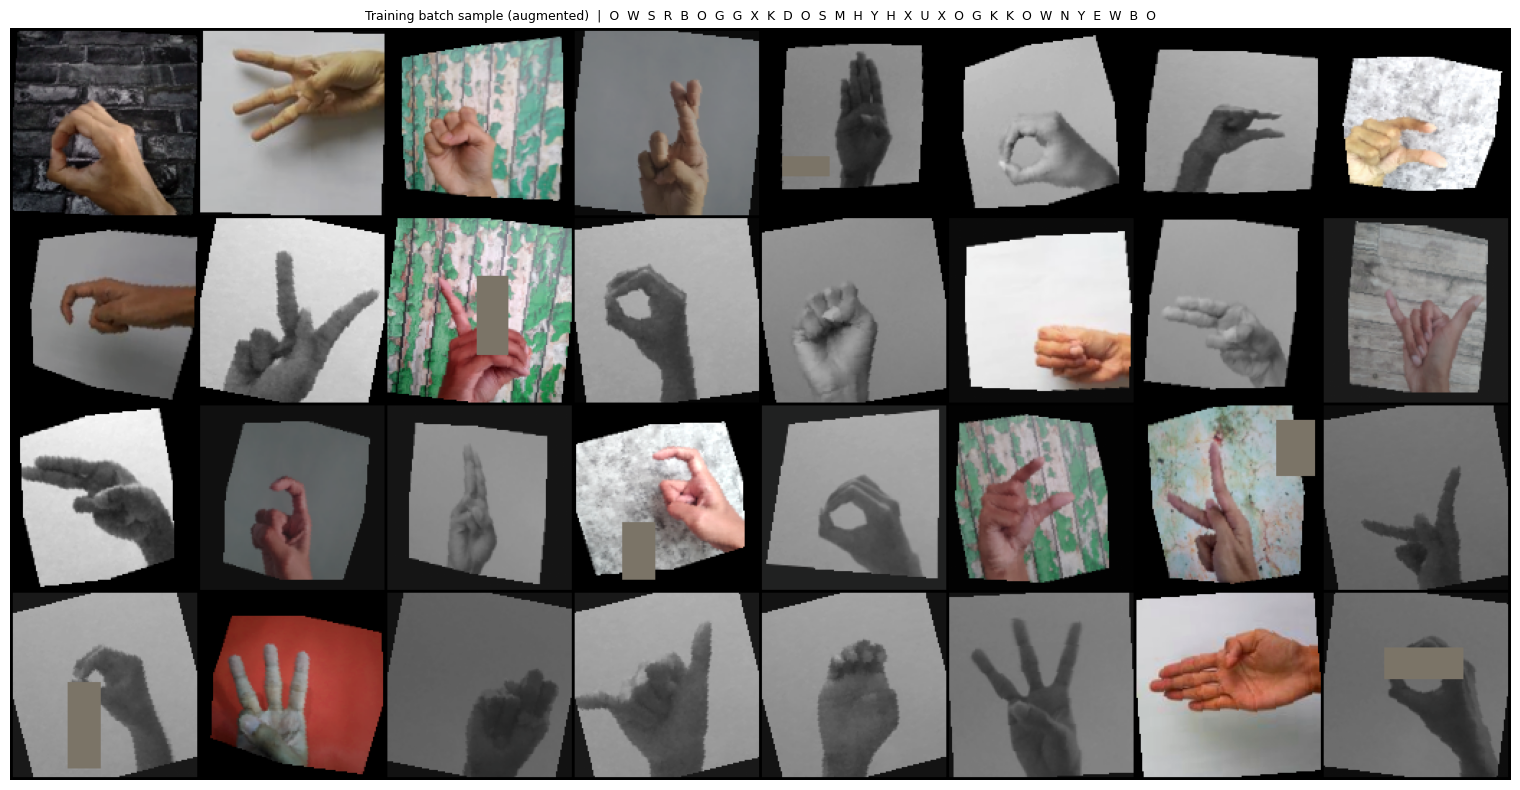

In [6]:
def denormalise(tensor: torch.Tensor) -> torch.Tensor:
    """Reverse ImageNet normalisation for display."""
    mean = torch.tensor(_MEAN).view(3, 1, 1)
    std  = torch.tensor(_STD ).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)


imgs, labels = next(iter(train_loader))
grid = make_grid(denormalise(imgs[:32]), nrow=8, padding=2)

plt.figure(figsize=(16, 8))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Training batch sample (augmented)  |  " +
          "  ".join(idx_to_class[l.item()] for l in labels[:32]),
          fontsize=9)
plt.axis("off")
plt.tight_layout()
plt.show()

### **Model Architecture**

In [ ]:
class DepthwiseSeparableConv(nn.Module):
    """
    Depthwise-separable convolution block.

    Replaces a standard 3×3 conv with a depthwise 3×3 followed by a
    pointwise 1×1, cutting FLOPs and parameters by ~8–9×.
    """

    def __init__(self, in_ch: int, out_ch: int, stride: int = 1) -> None:
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride=stride,
                            padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.bn(self.pw(self.dw(x))), inplace=True)


class ResLiteBlock(nn.Module):
    """
    Lightweight residual block using depthwise-separable convolutions.

    When ``stride > 1`` or ``in_ch != out_ch`` a 1×1 projection shortcut
    is added to match dimensions.
    """

    def __init__(self, in_ch: int, out_ch: int, stride: int = 1) -> None:
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(in_ch,  out_ch, stride=stride)
        self.conv2 = DepthwiseSeparableConv(out_ch, out_ch, stride=1)

        self.skip: nn.Module
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return F.relu(self.conv2(self.conv1(x)) + self.skip(x), inplace=True)


class SIBINet(nn.Module):
    """
    Lightweight CNN for SIBI alphabet classification.

    Architecture overview
    ---------------------
    Stem  : Conv 3→32, BN, ReLU, MaxPool  (128→64)
    Stage1: 2× ResLiteBlock  32→64         (64→32  via stride-2)
    Stage2: 2× ResLiteBlock  64→128        (32→16  via stride-2)
    Stage3: 2× ResLiteBlock 128→256        (16→8   via stride-2)
    Stage4: 2× ResLiteBlock 256→512        (8→4    via stride-2)
    Head  : AdaptiveAvgPool → Dropout → FC → num_classes

    Total params: ~2.1 M  |  VRAM (FP16, batch 64): ~0.6 GB

    Parameters
    ----------
    num_classes : Number of output classes (24 for SIBI A–Y)
    dropout     : Dropout probability before the final FC layer
    """

    def __init__(self, num_classes: int = 24, dropout: float = 0.4) -> None:
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 128 → 64
        )

        # Residual stages
        self.stage1 = self._make_stage(32,  64,  n_blocks=2, stride=2)  # 64→32
        self.stage2 = self._make_stage(64,  128, n_blocks=2, stride=2)  # 32→16
        self.stage3 = self._make_stage(128, 256, n_blocks=2, stride=2)  # 16→8
        self.stage4 = self._make_stage(256, 512, n_blocks=2, stride=2)  # 8→4

        # Classification head
        self.pool    = nn.AdaptiveAvgPool2d(1)          # → (B, 512, 1, 1)
        self.dropout = nn.Dropout(p=dropout)
        self.fc      = nn.Linear(512, num_classes)

        self._init_weights()

    # helpers 

    @staticmethod
    def _make_stage(
        in_ch: int,
        out_ch: int,
        n_blocks: int,
        stride: int,
    ) -> nn.Sequential:
        """Stack ``n_blocks`` ResLiteBlocks; the first uses ``stride``."""
        layers = [ResLiteBlock(in_ch, out_ch, stride=stride)]
        for _ in range(1, n_blocks):
            layers.append(ResLiteBlock(out_ch, out_ch, stride=1))
        return nn.Sequential(*layers)

    def _init_weights(self) -> None:
        """Kaiming-normal init for Conv2d; constant init for BN."""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    # forward 

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Parameters
        ----------
        x : (B, 3, H, W) normalised image tensor

        Returns
        -------
        logits : (B, num_classes) raw scores
        """
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x).flatten(1)
        x = self.dropout(x)
        return self.fc(x)


# Instantiate & inspect 
model = SIBINet(
    num_classes=CFG["num_classes"],
    dropout=CFG["dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable:,}")

# Quick shape sanity-check
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    out   = model(dummy)
    print(f"Output shape (batch=1): {out.shape}  — expected (1, {CFG['num_classes']})")

Total parameters    : 1,445,720
Trainable parameters: 1,445,720
Output shape (batch=1): torch.Size([1, 24])  — expected (1, 24)


### **Loss, Optimiser & Scheduler**

In [8]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=CFG["label_smoothing"]
)

optimizer = AdamW(
    model.parameters(),
    lr           = CFG["lr_max"] / 10,  # OneCycleLR starts below peak
    weight_decay = CFG["weight_decay"],
)

scheduler = OneCycleLR(
    optimizer,
    max_lr          = CFG["lr_max"],
    epochs          = CFG["epochs"],
    steps_per_epoch = len(train_loader),
    pct_start       = 0.3,        # 30 % warm-up, 70 % anneal
    anneal_strategy = "cos",
    div_factor      = 10.0,       # initial_lr = max_lr / 10
    final_div_factor= 1e4,        # final_lr   = initial_lr / 1e4
)

# AMP scaler (no-op on CPU)
scaler = GradScaler(enabled=CFG["use_amp"])

print(f"Loss      : CrossEntropyLoss (label_smoothing={CFG['label_smoothing']})")
print(f"Optimiser : AdamW (lr={CFG['lr_max']/10:.2e}, wd={CFG['weight_decay']})")
print(f"Scheduler : OneCycleLR (max_lr={CFG['lr_max']:.2e}, epochs={CFG['epochs']})")
print(f"AMP FP16  : {CFG['use_amp']}")

Loss      : CrossEntropyLoss (label_smoothing=0.05)
Optimiser : AdamW (lr=3.00e-04, wd=0.0001)
Scheduler : OneCycleLR (max_lr=3.00e-03, epochs=50)
AMP FP16  : True


C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\2793506721.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG["use_amp"])


### **Training & Validation Loop**

In [9]:
def train_one_epoch(
    model     : nn.Module,
    loader    : DataLoader,
    criterion : nn.Module,
    optimizer : torch.optim.Optimizer,
    scheduler : torch.optim.lr_scheduler._LRScheduler,
    scaler    : GradScaler,
    device    : torch.device,
    use_amp   : bool,
) -> Tuple[float, float]:
    """
    Train for one epoch.

    Returns
    -------
    (avg_loss, accuracy)
    """
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # zero_grad with set_to_none is faster

        with autocast(enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += bs

    return total_loss / n, correct / n


@torch.no_grad()
def evaluate(
    model    : nn.Module,
    loader   : DataLoader,
    criterion: nn.Module,
    device   : torch.device,
    use_amp  : bool,
) -> Tuple[float, float]:
    """
    Evaluate the model on a DataLoader.

    Returns
    -------
    (avg_loss, accuracy)
    """
    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with autocast(enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += bs

    return total_loss / n, correct / n


print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [10]:
# Main training loop with early stopping and best-model checkpointing

history: Dict[str, List[float]] = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : [],
    "lr"        : [],
}

best_val_acc: float     = 0.0
patience_counter: int   = 0
best_model_path: Path   = OUTPUT_DIR / CFG["model_filename"]

print(f"Training for up to {CFG['epochs']} epochs  "
      f"(early-stop patience={CFG['patience']})\n")

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer,
        scheduler, scaler, DEVICE, CFG["use_amp"]
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, DEVICE, CFG["use_amp"]
    )

    current_lr = scheduler.get_last_lr()[0]
    elapsed    = time.time() - t0

    history["train_loss"].append(train_loss)
    history["train_acc" ].append(train_acc)
    history["val_loss"  ].append(val_loss)
    history["val_acc"   ].append(val_acc)
    history["lr"        ].append(current_lr)

    # Best-model checkpoint
    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            "epoch"       : epoch,
            "model_state" : model.state_dict(),
            "optim_state" : optimizer.state_dict(),
            "val_acc"     : val_acc,
            "class_to_idx": class_to_idx,
            "cfg"         : CFG,
        }, best_model_path)
    else:
        patience_counter += 1

    marker = " ✓ (saved)" if improved else ""
    print(
        f"Epoch {epoch:3d}/{CFG['epochs']}  "
        f"| train {train_loss:.4f}/{train_acc:.3f}  "
        f"| val {val_loss:.4f}/{val_acc:.3f}  "
        f"| lr {current_lr:.2e}  "
        f"| {elapsed:.1f}s"
        f"{marker}"
    )

    # Early stopping
    if patience_counter >= CFG["patience"]:
        print(f"\nEarly stop triggered at epoch {epoch} "
              f"(no improvement for {CFG['patience']} epochs).")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")
print(f"Best model saved to     : {best_model_path}")

Training for up to 50 epochs  (early-stop patience=10)



C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\748356119.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):
d:\1_KULIAH SMT 6\MACHINE LEARNING\sibi_ai\.venv\lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\748356119.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Epoch   1/50  | train 4.0255/0.043  | val 3.2597/0.057  | lr 3.30e-04  | 359.6s ✓ (saved)
Epoch   2/50  | train 3.7791/0.048  | val 3.2024/0.061  | lr 4.17e-04  | 239.6s ✓ (saved)
Epoch   3/50  | train 3.5773/0.052  | val 3.1237/0.091  | lr 5.58e-04  | 181.6s ✓ (saved)
Epoch   4/50  | train 3.3135/0.078  | val 2.9672/0.106  | lr 7.48e-04  | 187.0s ✓ (saved)
Epoch   5/50  | train 2.9750/0.146  | val 2.5516/0.250  | lr 9.76e-04  | 191.1s ✓ (saved)
Epoch   6/50  | train 2.4864/0.257  | val 2.3079/0.326  | lr 1.23e-03  | 182.5s ✓ (saved)
Epoch   7/50  | train 2.1055/0.373  | val 1.7228/0.509  | lr 1.51e-03  | 186.5s ✓ (saved)
Epoch   8/50  | train 1.7574/0.495  | val 1.5032/0.585  | lr 1.79e-03  | 186.6s ✓ (saved)
Epoch   9/50  | train 1.5346/0.578  | val 1.5911/0.564  | lr 2.07e-03  | 176.6s
Epoch  10/50  | train 1.4106/0.627  | val 2.0356/0.518  | lr 2.33e-03  | 177.8s
Epoch  11/50  | train 1.2946/0.662  | val 1.2276/0.694  | lr 2.56e-03  | 177.3s ✓ (saved)
Epoch  12/50  | train 1.1317/0

### **Training Curves**

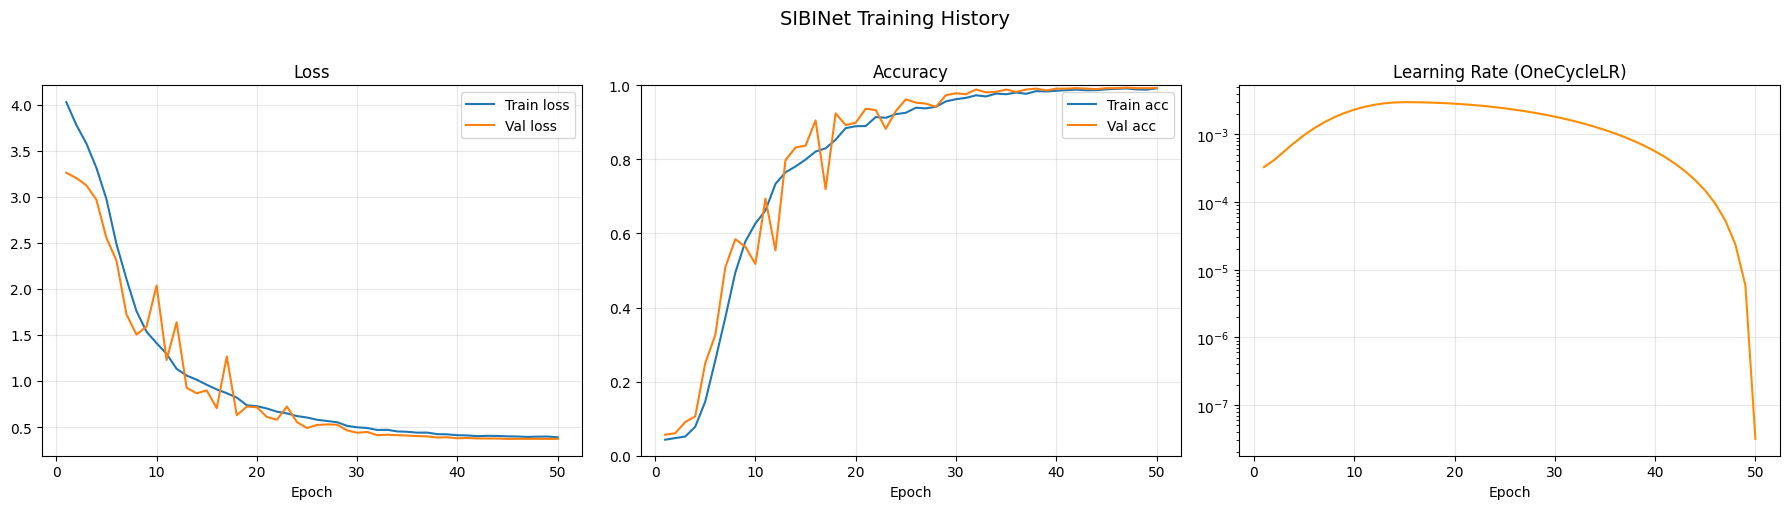

In [11]:
def plot_training_history(history: Dict[str, List[float]]) -> None:
    """Plot loss, accuracy, and learning-rate curves."""
    epochs_ran = len(history["train_loss"])
    ep = range(1, epochs_ran + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(ep, history["train_loss"], label="Train loss")
    axes[0].plot(ep, history["val_loss"],   label="Val loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(ep, history["train_acc"], label="Train acc")
    axes[1].plot(ep, history["val_acc"],   label="Val acc")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # LR schedule
    axes[2].plot(ep, history["lr"], color="darkorange")
    axes[2].set_title("Learning Rate (OneCycleLR)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_yscale("log")
    axes[2].grid(alpha=0.3)

    plt.suptitle("SIBINet Training History", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


plot_training_history(history)

### **Final Evaluation on Test Set**

In [12]:
# Load the best checkpoint before evaluating
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_acc={checkpoint['val_acc']:.4f})")

test_loss, test_acc = evaluate(
    model, test_loader, criterion, DEVICE, CFG["use_amp"]
)
print(f"\nTest loss : {test_loss:.4f}")
print(f"Test acc  : {test_acc:.4f}  ({test_acc*100:.1f} %)")

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\2516263851.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location=DEVICE)


Loaded best model from epoch 47 (val_acc=0.9937)


C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\748356119.py:68: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):



Test loss : 0.3756
Test acc  : 0.9905  (99.1 %)


### **Per-Class Report & Confusion Matrix**

In [13]:
@torch.no_grad()
def collect_predictions(
    model : nn.Module,
    loader: DataLoader,
    device: torch.device,
    use_amp: bool,
) -> Tuple[List[int], List[int]]:
    """Collect all predictions and ground-truth labels from a loader."""
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device, non_blocking=True)
        with autocast(enabled=use_amp):
            logits = model(imgs)
        all_preds.extend(logits.argmax(1).cpu().tolist())
        all_labels.extend(labels.tolist())
    return all_labels, all_preds


y_true, y_pred = collect_predictions(
    model, test_loader, DEVICE, CFG["use_amp"]
)

class_names = [idx_to_class[i] for i in range(CFG["num_classes"])]

print("\nPer-class Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\2988253452.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):



Per-class Classification Report:
              precision    recall  f1-score   support

           A      1.000     1.000     1.000        14
           B      1.000     1.000     1.000        23
           C      1.000     1.000     1.000        23
           D      1.000     1.000     1.000        28
           E      1.000     0.966     0.982        29
           F      1.000     1.000     1.000        22
           G      1.000     1.000     1.000        22
           H      1.000     1.000     1.000        18
           I      1.000     1.000     1.000        19
           K      1.000     0.913     0.955        23
           L      1.000     1.000     1.000        14
           M      1.000     0.926     0.962        27
           N      0.900     1.000     0.947        18
           O      1.000     1.000     1.000        16
           P      0.917     1.000     0.957        22
           Q      1.000     1.000     1.000        20
           R      1.000     1.000     1.000    

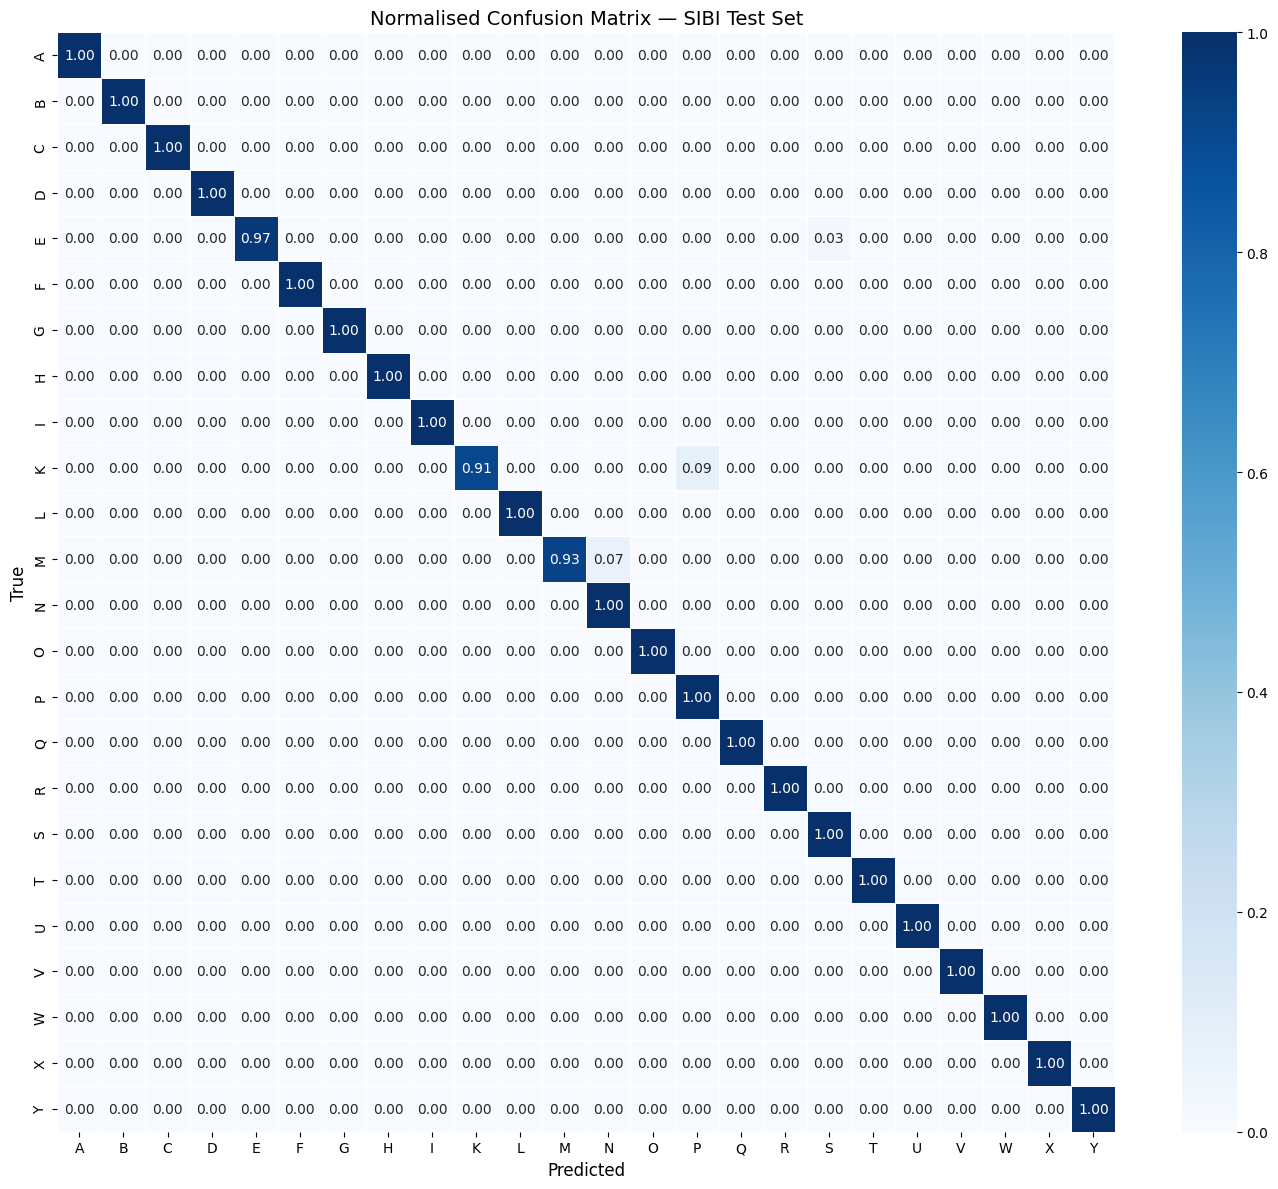

In [14]:
# Normalised confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot    = True,
    fmt      = ".2f",
    cmap     = "Blues",
    xticklabels = class_names,
    yticklabels = class_names,
    linewidths  = 0.4,
    ax          = ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True",      fontsize=12)
ax.set_title ("Normalised Confusion Matrix — SIBI Test Set", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

### **VRAM & Performance Profile**

In [15]:
if DEVICE.type == "cuda":
    allocated = torch.cuda.max_memory_allocated(0) / 1e9
    reserved  = torch.cuda.max_memory_reserved(0)  / 1e9
    print(f"Peak VRAM allocated : {allocated:.2f} GB")
    print(f"Peak VRAM reserved  : {reserved:.2f} GB")

    # Quick throughput benchmark (inference)
    model.eval()
    dummy_batch = torch.randn(64, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    # Warm-up
    for _ in range(5):
        with autocast(enabled=CFG["use_amp"]), torch.no_grad():
            _ = model(dummy_batch)
    torch.cuda.synchronize()

    t0 = time.perf_counter()
    RUNS = 50
    for _ in range(RUNS):
        with autocast(enabled=CFG["use_amp"]), torch.no_grad():
            _ = model(dummy_batch)
    torch.cuda.synchronize()
    elapsed_ms = (time.perf_counter() - t0) * 1000 / RUNS

    print(f"\nInference latency (batch=64, FP16): {elapsed_ms:.2f} ms/batch")
    print(f"Throughput : {64 / (elapsed_ms / 1000):.0f} images/sec")
    print(f"Per-image  : {elapsed_ms / 64 * 1000:.2f} µs")
else:
    print("CUDA not available — skipping VRAM profile.")

Peak VRAM allocated : 0.56 GB
Peak VRAM reserved  : 0.73 GB


C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\1437525630.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]), torch.no_grad():
C:\Users\LOQ\AppData\Local\Temp\ipykernel_6084\1437525630.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG["use_amp"]), torch.no_grad():



Inference latency (batch=64, FP16): 15.29 ms/batch
Throughput : 4186 images/sec
Per-image  : 238.89 µs


### **Export Summary**

In [17]:
output_files = list(OUTPUT_DIR.iterdir())
print("Output files:")
for f in sorted(output_files):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<35}  {size_kb:>8.1f} KB")

print("\n Training complete.")
print(f"   Best val accuracy : {best_val_acc:.4f}  ({best_val_acc*100:.1f} %)")
print(f"   Test accuracy     : {test_acc:.4f}  ({test_acc*100:.1f} %)")
print(f"   Model checkpoint  : {best_model_path}")
print(f"   Class map         : {OUTPUT_DIR / CFG['class_map_file']}")

Output files:
  class_to_idx.json                         0.3 KB
  confusion_matrix.png                    129.2 KB
  sibi_cnn_best.pth                     17098.4 KB
  training_curves.png                     115.2 KB

 Training complete.
   Best val accuracy : 0.9937  (99.4 %)
   Test accuracy     : 0.9905  (99.1 %)
   Model checkpoint  : outputs\sibi_cnn_best.pth
   Class map         : outputs\class_to_idx.json
